<a href="https://colab.research.google.com/github/JaredOzarzak/biomechanics-analysis-pipeline/blob/main/Equipment_Recommendation_Prototype_process.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install scikit-learn pandas numpy matplotlib seaborn joblib --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error

In [2]:
np.random.seed(42)

n = 120

df = pd.DataFrame({
    "player_id": np.random.choice([f"Player_{i:02}" for i in range(1, 31)], size=n),
    "swing_id": np.arange(1, n + 1),
    "club_model": np.random.choice(["Model_A", "Model_B", "Model_C"], size=n),
    "loft": np.random.choice([8.5, 9.0, 9.5, 10.5, 11.0], size=n),
    "shaft_flex": np.random.choice(["Regular", "Stiff", "X-Stiff"], size=n),
    "pelvis_ang_vel": np.random.normal(340, 45, n),
    "thorax_ang_vel": np.random.normal(470, 55, n),
    "xfactor_peak_timing": np.random.normal(0.42, 0.06, n),
    "grf_peak": np.random.normal(1.35, 0.22, n),
    "launch_angle": np.random.normal(12.5, 2.0, n),
    "spin": np.random.normal(2600, 350, n),
})

df["ball_speed"] = (
    0.12 * df["thorax_ang_vel"] +
    9.5 * df["grf_peak"] -
    0.004 * df["spin"] +
    np.random.normal(0, 3, n)
)

df["clubhead_speed"] = (
    0.10 * df["pelvis_ang_vel"] +
    0.08 * df["thorax_ang_vel"] +
    6.0 * df["grf_peak"] -
    15 * df["xfactor_peak_timing"] +
    np.random.normal(0, 2.5, n)
)

df["smash"] = df["ball_speed"] / df["clubhead_speed"]
df["carry"] = (
    1.7 * df["ball_speed"] +
    2.5 * df["launch_angle"] -
    0.015 * df["spin"] +
    np.random.normal(0, 8, n)
)

df.to_csv("sample_data.csv", index=False)

df.head()

,player_id,swing_id,club_model,loft,shaft_flex,pelvis_ang_vel,thorax_ang_vel,xfactor_peak_timing,grf_peak,launch_angle,spin,ball_speed,clubhead_speed,smash,carry
0,Player_07,1,Model_B,8.5,Stiff,356.978332,364.801142,0.396716,1.397709,9.451970,2305.681921,47.041683,68.008866,0.691699,80.691505
1,Player_20,2,Model_A,11.0,X-Stiff,414.310794,489.936205,0.379896,1.447266,10.903122,2597.102674,60.943089,81.984348,0.743350,78.422029
2,Player_29,3,Model_A,8.5,Regular,280.292571,501.424113,0.503744,1.405054,15.182624,2843.166361,69.352317,71.700068,0.967256,115.723071
3,Player_15,4,Model_A,8.5,Regular,422.967211,523.378810,0.341421,1.099254,10.732444,2228.710621,64.265719,85.231332,0.754015,102.635503
4,Player_11,5,Model_A,9.5,Regular,307.116637,510.807966,0.305173,1.054882,13.647934,1381.716910,67.366134,74.696033,0.901870,131.232844


In [3]:
print("Dataset shape:", df.shape)
print("\nMissing values:")
print(df.isna().sum())

df.describe()

Dataset shape: (120, 15)

Missing values:
player_id              0
swing_id               0
club_model             0
loft                   0
shaft_flex             0
pelvis_ang_vel         0
thorax_ang_vel         0
xfactor_peak_timing    0
grf_peak               0
launch_angle           0
spin                   0
ball_speed             0
clubhead_speed         0
smash                  0
carry                  0
dtype: int64


,swing_id,loft,pelvis_ang_vel,thorax_ang_vel,xfactor_peak_timing,grf_peak,launch_angle,spin,ball_speed,clubhead_speed,smash,carry
count,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000
mean,60.500000,9.604167,347.133767,470.704910,0.419228,1.326715,12.312702,2600.843353,58.936936,74.174733,0.796378,91.049263
std,34.785054,0.909557,46.443770,55.811860,0.062246,0.233302,2.021059,313.549165,7.835920,6.806989,0.094808,17.645070
min,1.000000,8.500000,245.949201,334.878912,0.255543,0.764943,7.530777,1381.716910,38.998902,52.780273,0.567178,48.758164
25%,30.750000,8.500000,318.415998,438.410197,0.384217,1.170294,10.841568,2412.013173,53.605895,70.136550,0.735581,79.604868
50%,60.500000,9.500000,343.164064,469.424772,0.421312,1.327442,12.361679,2621.378046,59.147915,74.544304,0.791332,88.388851
75%,90.250000,10.500000,381.176672,510.882285,0.462213,1.467434,13.790724,2801.391533,64.342728,78.802637,0.844545,103.209928
max,120.000000,11.000000,445.659862,600.588117,0.587027,1.915384,17.214753,3465.297812,79.077605,91.585877,1.076058,135.030847


In [4]:
df = df.dropna(subset=["clubhead_speed"])

features = [
    "pelvis_ang_vel",
    "thorax_ang_vel",
    "xfactor_peak_timing",
    "grf_peak",
    "launch_angle",
    "spin",
    "ball_speed",
    "carry"
]

for col in features:
    df[col] = df[col].fillna(df[col].median())

In [5]:
df["tempo_ratio"] = df["thorax_ang_vel"] / (df["pelvis_ang_vel"] + 1e-6)
df["grf_norm"] = df["grf_peak"] / (df["grf_peak"].max() + 1e-6)
df["speed_efficiency"] = df["clubhead_speed"] / (df["pelvis_ang_vel"] + 1e-6)

model_features = [
    "pelvis_ang_vel",
    "thorax_ang_vel",
    "xfactor_peak_timing",
    "grf_norm",
    "tempo_ratio",
    "launch_angle",
    "spin",
    "ball_speed"
]

X = df[model_features]
y = df["clubhead_speed"]

X.head()

,pelvis_ang_vel,thorax_ang_vel,xfactor_peak_timing,grf_norm,tempo_ratio,launch_angle,spin,ball_speed
0,356.978332,364.801142,0.396716,0.729728,1.021914,9.451970,2305.681921,47.041683
1,414.310794,489.936205,0.379896,0.755600,1.182533,10.903122,2597.102674,60.943089
2,280.292571,501.424113,0.503744,0.733562,1.788931,15.182624,2843.166361,69.352317
3,422.967211,523.378810,0.341421,0.573908,1.237398,10.732444,2228.710621,64.265719
4,307.116637,510.807966,0.305173,0.550742,1.663238,13.647934,1381.716910,67.366134


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [7]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("rf", RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        max_depth=6
    ))
])

pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('rf',
                 RandomForestRegressor(max_depth=6, n_estimators=200,
                                       random_state=42))])

In [8]:
preds = pipeline.predict(X_test)

r2 = r2_score(y_test, preds)
mae = mean_absolute_error(y_test, preds)

print("Model Performance")
print("-----------------")
print("R²:", round(r2, 3))
print("MAE:", round(mae, 3), "mph")

Model Performance
-----------------
R²: 0.582
MAE: 3.621 mph


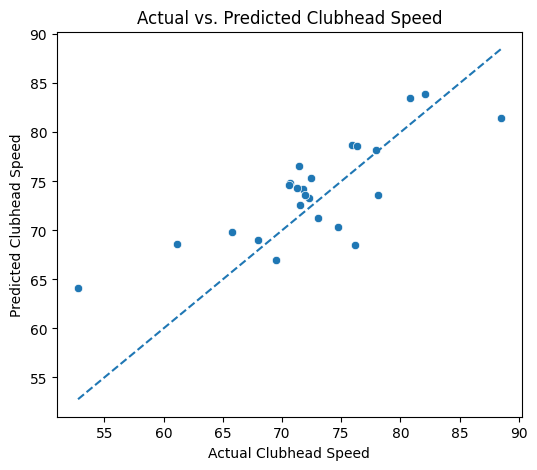

In [9]:
plt.figure(figsize=(6, 5))
sns.scatterplot(x=y_test, y=preds)
plt.xlabel("Actual Clubhead Speed")
plt.ylabel("Predicted Clubhead Speed")
plt.title("Actual vs. Predicted Clubhead Speed")

min_val = min(y_test.min(), preds.min())
max_val = max(y_test.max(), preds.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.show()

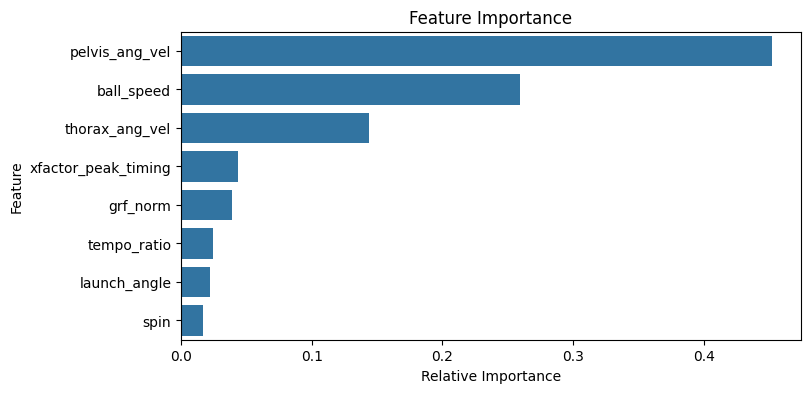

,0
pelvis_ang_vel,0.451778
ball_speed,0.258970
thorax_ang_vel,0.143564
xfactor_peak_timing,0.043673
grf_norm,0.039126
tempo_ratio,0.024117
launch_angle,0.022142
spin,0.016631


In [10]:
importances = pipeline.named_steps["rf"].feature_importances_

feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(x=feat_imp.values, y=feat_imp.index)
plt.title("Feature Importance")
plt.xlabel("Relative Importance")
plt.ylabel("Feature")
plt.show()

feat_imp

In [11]:
df_preds = X_test.copy()
df_preds["actual_clubhead_speed"] = y_test.values
df_preds["predicted_clubhead_speed"] = preds
df_preds["prediction_error"] = df_preds["predicted_clubhead_speed"] - df_preds["actual_clubhead_speed"]

df_preds.head()

,pelvis_ang_vel,thorax_ang_vel,xfactor_peak_timing,grf_norm,tempo_ratio,launch_angle,spin,ball_speed,actual_clubhead_speed,predicted_clubhead_speed,prediction_error
44,311.663461,446.149232,0.383882,0.999999,1.431510,13.393279,3023.143680,58.134713,73.016594,71.256702,-1.759892
47,308.044242,549.438634,0.466298,0.399368,1.783635,12.339168,2742.979322,61.895474,76.189642,68.477712,-7.711930
4,307.116637,510.807966,0.305173,0.550742,1.663238,13.647934,1381.716910,67.366134,74.696033,70.346566,-4.349467
55,351.773038,488.188531,0.514808,0.765438,1.387794,12.769969,2644.730944,67.274216,71.474925,76.552752,5.077827
26,254.618036,394.727544,0.542599,0.704055,1.550273,10.324438,2358.660888,51.087356,52.780273,64.097020,11.316747


In [12]:
def recommend_config(pred_speed):
    if pred_speed < 85:
        return "Higher loft / regular shaft"
    elif pred_speed < 95:
        return "Moderate loft / stiff shaft"
    else:
        return "Lower loft / stiff or X-stiff shaft"

df_preds["recommended_config"] = df_preds["predicted_clubhead_speed"].apply(recommend_config)

df_preds[[
    "predicted_clubhead_speed",
    "actual_clubhead_speed",
    "prediction_error",
    "recommended_config"
]].head(10)

,predicted_clubhead_speed,actual_clubhead_speed,prediction_error,recommended_config
44,71.256702,73.016594,-1.759892,Higher loft / regular shaft
47,68.477712,76.189642,-7.711930,Higher loft / regular shaft
4,70.346566,74.696033,-4.349467,Higher loft / regular shaft
55,76.552752,71.474925,5.077827,Higher loft / regular shaft
26,64.097020,52.780273,11.316747,Higher loft / regular shaft
64,83.865876,82.049773,1.816103,Higher loft / regular shaft
73,74.237944,71.777310,2.460634,Higher loft / regular shaft
10,72.547772,71.513929,1.033843,Higher loft / regular shaft
40,69.835775,65.774189,4.061586,Higher loft / regular shaft
107,74.821358,70.720982,4.100376,Higher loft / regular shaft


In [13]:
df_preds.to_csv("predictions_summary.csv", index=False)
joblib.dump(pipeline, "equipment_recommendation_model.joblib")

print("Saved files:")
print("- predictions_summary.csv")
print("- equipment_recommendation_model.joblib")

Saved files:
- predictions_summary.csv
- equipment_recommendation_model.joblib


In [15]:
from google.colab import files

files.download("sample_data.csv")
files.download("predictions_summary.csv")
files.download("equipment_recommendation_model.joblib")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>